In [20]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [22]:
df = pd.read_csv('reddit_posts_cleaned.csv')
print(f"Loaded {len(df)} posts")

Loaded 17213 posts


In [23]:
#PART 1: VADER SENTIMENT ANALYSIS
analyzer = SentimentIntensityAnalyzer()

In [24]:
#Scoring every post title
#compound score ranges from -1 (very negative) to +1 (very positive)
df['sentiment'] = df['title_clean'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
 
#Labeling each post as Positive, Neutral, or Negative
#Standard VADER thresholds: above 0.05 = positive, below -0.05 = negative
df['sentiment_label'] = pd.cut(
    df['sentiment'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)

In [25]:
#Average sentiment by period
print("\nMean Sentiment by Period")
period_sentiment = df.groupby('period')['sentiment'].mean()
print(period_sentiment.round(4))


Mean Sentiment by Period
period
Current Peak     0.0820
Post-Pandemic    0.1251
Pre-Pandemic     0.0974
Name: sentiment, dtype: float64


In [26]:
#Average sentiment by subreddit and period
print("\nMean Sentiment by Subreddit and Period")
sub_period = df.groupby(['subreddit', 'period'])['sentiment'].mean().unstack()
print(sub_period.round(4))


Mean Sentiment by Subreddit and Period
period           Current Peak  Post-Pandemic  Pre-Pandemic
subreddit                                                 
AnalogCommunity        0.0580         0.0873        0.0613
BuyItForLife           0.1320         0.2230        0.1416
GenZ                   0.0352         0.0445        0.0365
cassetteculture        0.1021         0.1581        0.1220
ipod                   0.0576         0.0932        0.0723
vinyl                  0.1065         0.1416        0.1500


In [27]:
#Sentiment label distribution by period
print("\nSentiment Distribution by Period")
label_dist = pd.crosstab(df['period'], df['sentiment_label'], normalize='index') * 100
print(label_dist.round(1))


Sentiment Distribution by Period
sentiment_label  Negative  Neutral  Positive
period                                      
Current Peak         12.7     58.8      28.6
Post-Pandemic        12.8     52.4      34.7
Pre-Pandemic         11.8     58.2      30.0


In [28]:
#PART 2: KEYWORD FREQUENCY CODING

#Defining the four keyword dictionaries:
#Each list captures how the underlying behavioural theory would naturally surface in informal Reddit language
 
#Brehm (1966) - Psychological Reactance Theory
reactance_words = [
    'sick of', 'tired of', 'done with', 'going back', 'fed up',
    'refuse', 'reject', 'escape', 'ditch', 'quit',
    'over it', 'hate streaming', 'anti', 'against',
    'leaving', 'gave up', 'switched from', 'abandoned',
    'dont need', 'dont want', 'no more', 'enough of'
]
 
#Berger & Heath (2007) - Identity Signalling
identity_words = [
    'aesthetic', 'vibe', 'vibes', 'retro', 'vintage',
    'cool', 'style', 'look', 'authentic', 'real',
    'unique', 'personality', 'statement', 'trendy',
    'hipster', 'core', 'era', 'mood'
]
 
#Wildschut et al. (2006) - Nostalgia as Affect Regulation
nostalgia_words = [
    'childhood', 'growing up', 'remember', 'miss',
    'used to', 'back in', 'old school', 'classic',
    'throwback', 'memory', 'memories', 'nostalgia',
    'nostalgic', 'reminds me', 'brings me back',
    'when i was', 'years ago'
]
 
#Kahneman et al. (1991) - Tangibility Premium / Endowment Effect
quality_words = [
    'sounds better', 'sound quality', 'warm', 'warmth',
    'tactile', 'tangible', 'physical', 'hold',
    'feel', 'texture', 'weight', 'real music',
    'analog', 'analogue', 'lossless', 'fidelity',
    'own', 'ownership', 'collection', 'shelf',
    'artwork', 'liner notes', 'album art'
]

In [29]:
#Checking each post for keywords from each category
 
def has_keywords(text, word_list):
    """Check if any keyword from the list appears in the text."""
    text = str(text).lower()
    return any(word in text for word in word_list)
 
df['has_reactance'] = df['title_clean'].apply(lambda x: has_keywords(x, reactance_words))
df['has_identity']  = df['title_clean'].apply(lambda x: has_keywords(x, identity_words))
df['has_nostalgia'] = df['title_clean'].apply(lambda x: has_keywords(x, nostalgia_words))
df['has_quality']   = df['title_clean'].apply(lambda x: has_keywords(x, quality_words))

In [31]:
#Proportions by period
print("\nKeyword Category Proportions by Period (%)")
keyword_cols = ['has_reactance', 'has_identity', 'has_nostalgia', 'has_quality']
keyword_by_period = df.groupby('period')[keyword_cols].mean() * 100
keyword_by_period.columns = ['Reactance', 'Identity', 'Nostalgia', 'Quality']
print(keyword_by_period.round(2))


Keyword Category Proportions by Period (%)
               Reactance  Identity  Nostalgia  Quality
period                                                
Current Peak        0.69     10.28       4.26     6.15
Post-Pandemic       1.04     11.62       5.60     7.50
Pre-Pandemic        0.67     10.72       6.27     8.02


In [32]:
# --- Proportions by subreddit and period ---
print("\nKeyword Proportions by Subreddit and Period (%)")
for cat, col in zip(['Reactance', 'Identity', 'Nostalgia', 'Quality'], keyword_cols):
    print(f"\n{cat}:")
    table = df.groupby(['subreddit', 'period'])[col].mean().unstack() * 100
    print(table.round(2))


Keyword Proportions by Subreddit and Period (%)

Reactance:
period           Current Peak  Post-Pandemic  Pre-Pandemic
subreddit                                                 
AnalogCommunity          0.20           0.87          0.90
BuyItForLife             0.50           0.33          0.40
GenZ                     1.73           1.08          1.12
cassetteculture          0.60           1.33          0.30
ipod                     0.30           1.31          0.60
vinyl                    0.81           1.38          0.70

Identity:
period           Current Peak  Post-Pandemic  Pre-Pandemic
subreddit                                                 
AnalogCommunity         18.22          21.57         16.42
BuyItForLife            14.50          11.82         11.20
GenZ                    11.99          10.96         16.53
cassetteculture          6.33           9.17          7.51
ipod                     6.44           8.82          7.51
vinyl                    4.13           6.6

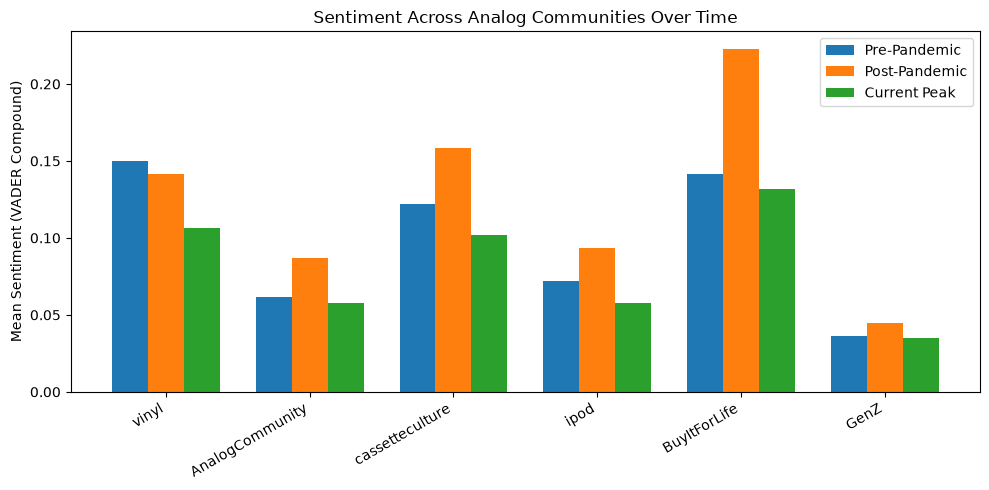

In [33]:
#PART 3: VISUALISATIONS
period_order = ['Pre-Pandemic', 'Post-Pandemic', 'Current Peak']

#Chart 1: Mean sentiment by subreddit and period
 
fig, ax = plt.subplots(figsize=(10, 5))
 
subreddits = df['subreddit'].unique()
x = np.arange(len(subreddits))
width = 0.25
 
for i, period in enumerate(period_order):
    means = [df[(df['subreddit'] == sub) & (df['period'] == period)]['sentiment'].mean()
             for sub in subreddits]
    ax.bar(x + i * width, means, width, label=period)
 
ax.set_xticks(x + width)
ax.set_xticklabels(subreddits, rotation=30, ha='right')
ax.set_ylabel('Mean Sentiment (VADER Compound)')
ax.set_title('Sentiment Across Analog Communities Over Time')
ax.legend()
ax.axhline(y=0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('01_sentiment_by_subreddit.png', dpi=150)
plt.show()

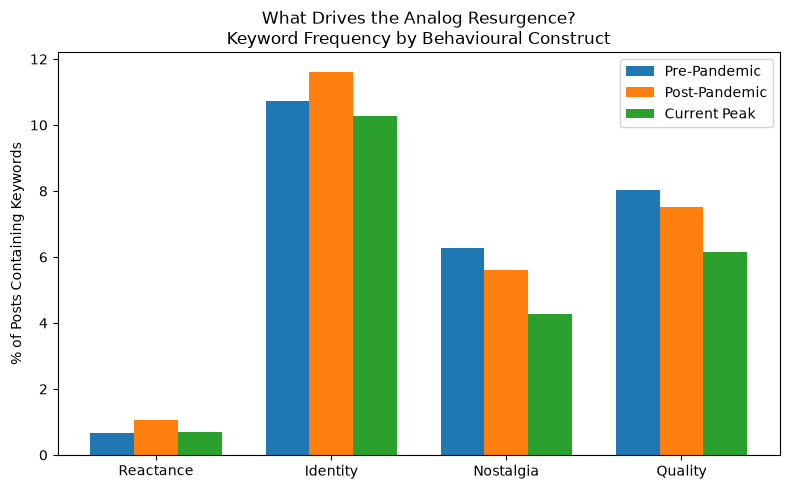

In [34]:
#Chart 2: Keyword category proportions by period
 
fig, ax = plt.subplots(figsize=(8, 5))
 
categories = ['Reactance', 'Identity', 'Nostalgia', 'Quality']
x = np.arange(len(categories))
width = 0.25
 
for i, period in enumerate(period_order):
    vals = keyword_by_period.loc[period, categories].values
    ax.bar(x + i * width, vals, width, label=period)
 
ax.set_xticks(x + width)
ax.set_xticklabels(categories)
ax.set_ylabel('% of Posts Containing Keywords')
ax.set_title('What Drives the Analog Resurgence?\nKeyword Frequency by Behavioural Construct')
ax.legend()
plt.tight_layout()
plt.savefig('02_keyword_proportions.png', dpi=150)
plt.show()

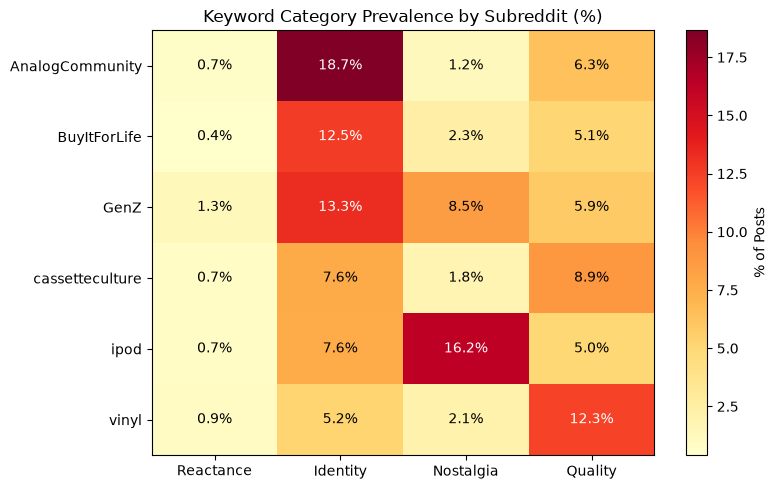

In [35]:
#Chart 3: Keyword proportions by subreddit (heatmap)
 
fig, ax = plt.subplots(figsize=(8, 5))
 
# Average across all periods for each subreddit
heatmap_data = df.groupby('subreddit')[keyword_cols].mean() * 100
heatmap_data.columns = categories
 
# Plot as a simple colour-coded table
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
 
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
 
# Add the numbers in each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(categories)):
        val = heatmap_data.values[i, j]
        color = 'white' if val > heatmap_data.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontsize=10)
 
ax.set_title('Keyword Category Prevalence by Subreddit (%)')
plt.colorbar(im, label='% of Posts')
plt.tight_layout()
plt.savefig('03_subreddit_heatmap.png', dpi=150)
plt.show()

In [39]:
#Saving scored dataset
df.to_csv('reddit_posts_analysed.csv', index=False)
 
# Save summary tables
period_sentiment.to_csv('sentiment_by_period.csv')
keyword_by_period.to_csv('keyword_proportions_by_period.csv')
 
print("\nAll outputs saved.")


All outputs saved.


In [41]:
## Google Trends and Sales Data ##

#Part 1: Google Trends (search interest over time)
#Part 2: RIAA & BPI sales data (behavioural validation)

In [42]:
#PART 1: GOOGLE TRENDS
filenames = {
    # Analog products
    'Vinyl Records': 'vinyl_record.csv',
    'Film Camera': 'film_camera.csv',
    'Digicam': 'digicam.csv',
    'Disposable Camera': 'disposable_camera.csv',
    'Record Player': 'record_player.csv',
    'Cassette Tape': 'cassette_tape.csv',
    'Wired Headphones': 'wired_headphones.csv',
    'iPod': 'ipod.csv',
    'MP3 Player': 'mp3_player.csv',
    'CD Player': 'cd_player.csv',
 
    # Digital counterparts
    'Spotify': 'spotify.csv',
    'AirPods': 'airpods.csv',
    'Streaming Music': 'streaming_music.csv',
    'Wireless Headphones': 'wireless_headphones.csv',
    'Smartphone Camera': 'smartphone_camera.csv',
}

In [43]:
# Load each file and extract the interest column
trends = pd.DataFrame()
 
for label, filename in filenames.items():
    try:
        # Google Trends CSVs: skip the first row (metadata),
        # second row becomes the header (Month, search term name)
        temp = pd.read_csv(filename, skiprows=1)
 
        # First column is the date, second is the interest value
        date_col = temp.columns[0]
        value_col = temp.columns[1]
 
        temp[date_col] = pd.to_datetime(temp[date_col])
        temp[value_col] = pd.to_numeric(temp[value_col], errors='coerce')
 
        temp = temp.rename(columns={date_col: 'date', value_col: label})
        temp = temp.set_index('date')
 
        trends = trends.join(temp[[label]], how='outer') if len(trends) > 0 else temp[[label]]
    except Exception as e:
        print(f"Could not load {filename}: {e}")
 
trends = trends.sort_index()
print(f"Loaded {len(trends.columns)} trends series")
print(f"Date range: {trends.index.min()} to {trends.index.max()}")
print(f"\nColumns: {trends.columns.tolist()}")

Loaded 15 trends series
Date range: 2010-02-01 00:00:00 to 2026-06-01 00:00:00

Columns: ['Vinyl Records', 'Film Camera', 'Digicam', 'Disposable Camera', 'Record Player', 'Cassette Tape', 'Wired Headphones', 'iPod', 'MP3 Player', 'CD Player', 'Spotify', 'AirPods', 'Streaming Music', 'Wireless Headphones', 'Smartphone Camera']


In [48]:

# --- Normalise each series to its own starting value ---
# This lets us compare GROWTH RATES across terms that have
# very different absolute search volumes
 
trends_norm = trends.copy()
for col in trends_norm.columns:
    first_valid = trends_norm[col].first_valid_index()
    if first_valid is not None:
        baseline = trends_norm.loc[first_valid, col]
        if baseline > 0:
            trends_norm[col] = (trends_norm[col] / baseline) * 100
 
# --- Define groups ---
analog_terms = ['Vinyl Records', 'Film Camera', 'Digicam', 'Disposable Camera',
                'Record Player', 'Cassette Tape', 'Wired Headphones',
                'iPod', 'MP3 Player', 'CD Player']
 
digital_terms = ['Spotify', 'AirPods', 'Streaming Music',
                 'Wireless Headphones', 'Smartphone Camera']
 
# Only keep terms that actually loaded
analog_terms = [t for t in analog_terms if t in trends_norm.columns]
digital_terms = [t for t in digital_terms if t in trends_norm.columns]

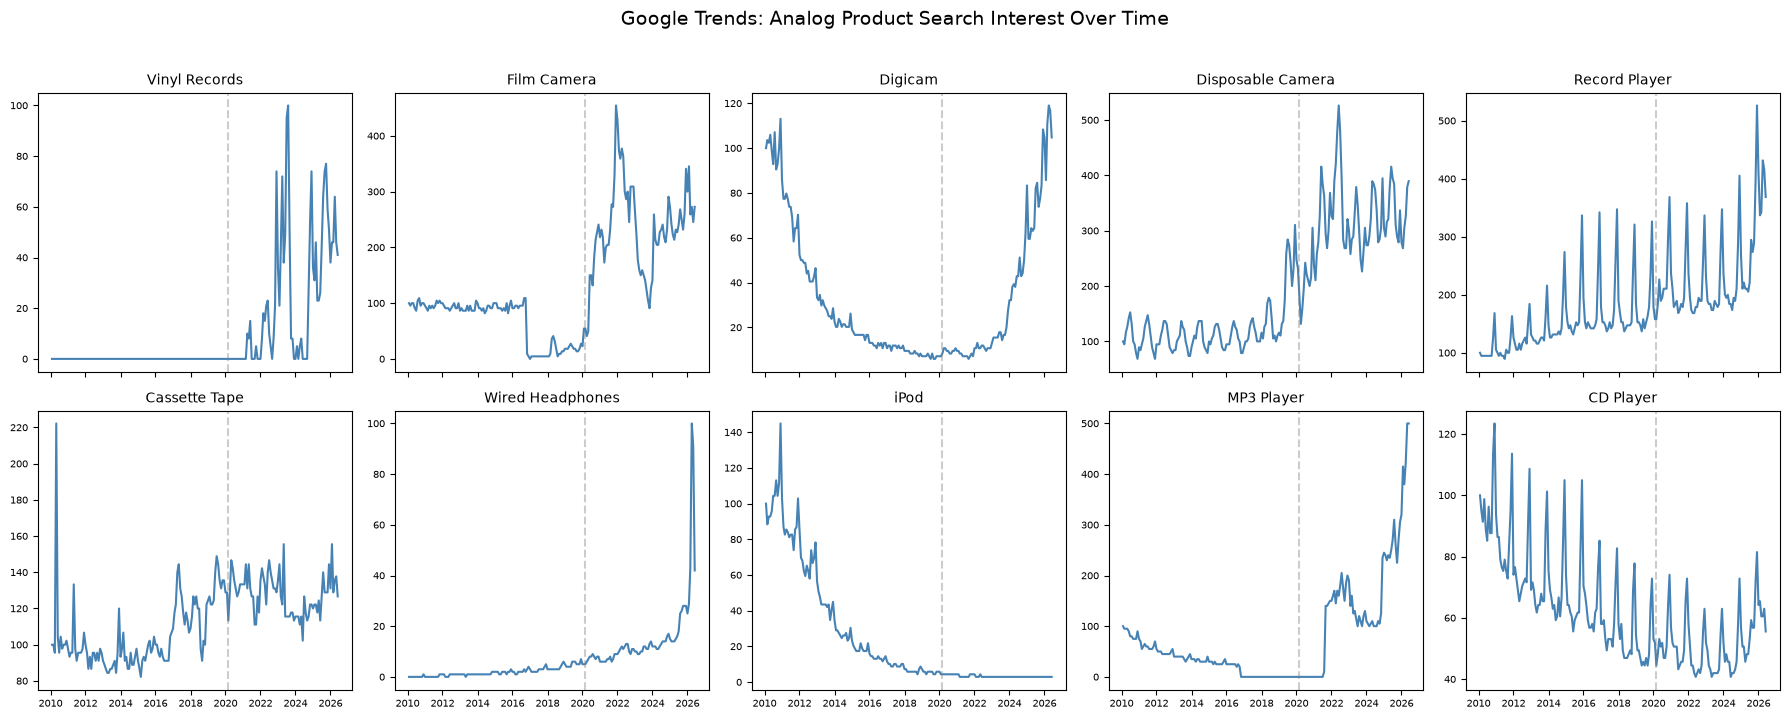

In [49]:
# --- Chart 1: Analog products over time (small multiples) ---
 
rows = 2
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(18, 7), sharex=True)
 
for i, (ax, term) in enumerate(zip(axes.flat, analog_terms)):
    ax.plot(trends_norm.index, trends_norm[term], linewidth=1.5, color='steelblue')
    ax.set_title(term, fontsize=10)
    ax.axvline(pd.Timestamp('2020-03-01'), color='grey', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=7)
 
# Hide any unused subplots if there are fewer terms than grid slots
for j in range(len(analog_terms), rows * cols):
    axes.flat[j].set_visible(False)
 
fig.suptitle('Google Trends: Analog Product Search Interest Over Time',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('layer1_analog_trends.png', dpi=150)
plt.show()

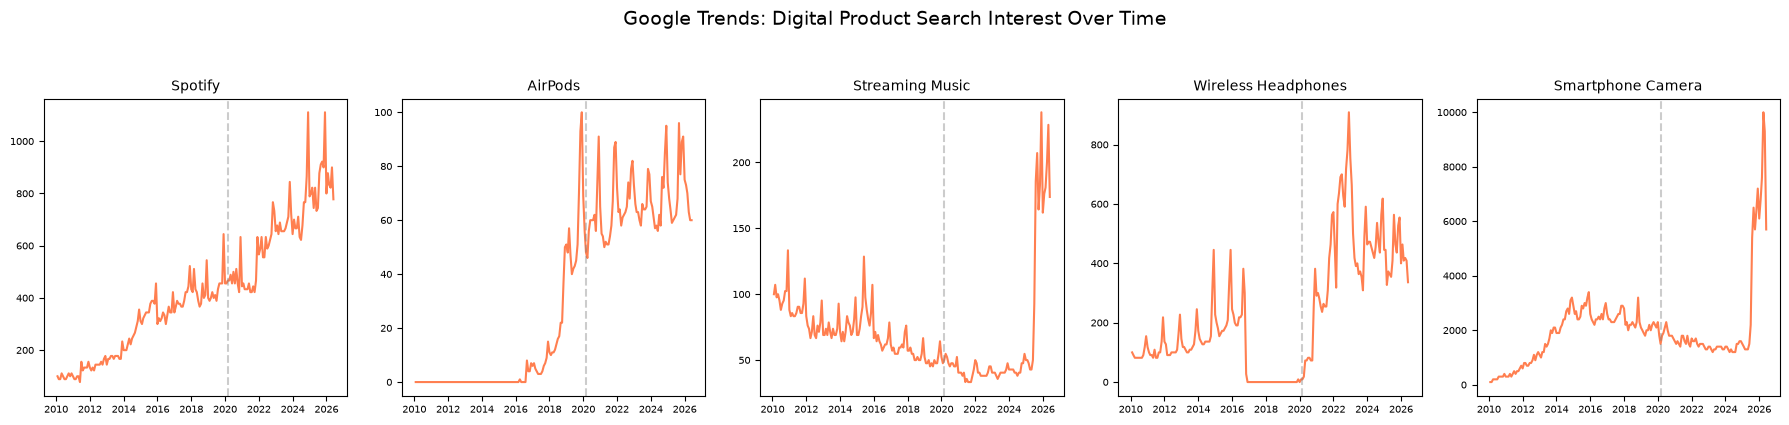

In [50]:
# --- Chart 2: Digital counterparts over time (small multiples) ---
 
fig, axes = plt.subplots(1, len(digital_terms), figsize=(18, 4), sharex=True)
 
for ax, term in zip(axes.flat, digital_terms):
    ax.plot(trends_norm.index, trends_norm[term], linewidth=1.5, color='coral')
    ax.set_title(term, fontsize=10)
    ax.axvline(pd.Timestamp('2020-03-01'), color='grey', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=7)
 
fig.suptitle('Google Trends: Digital Product Search Interest Over Time',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('layer1_digital_trends.png', dpi=150)
plt.show()

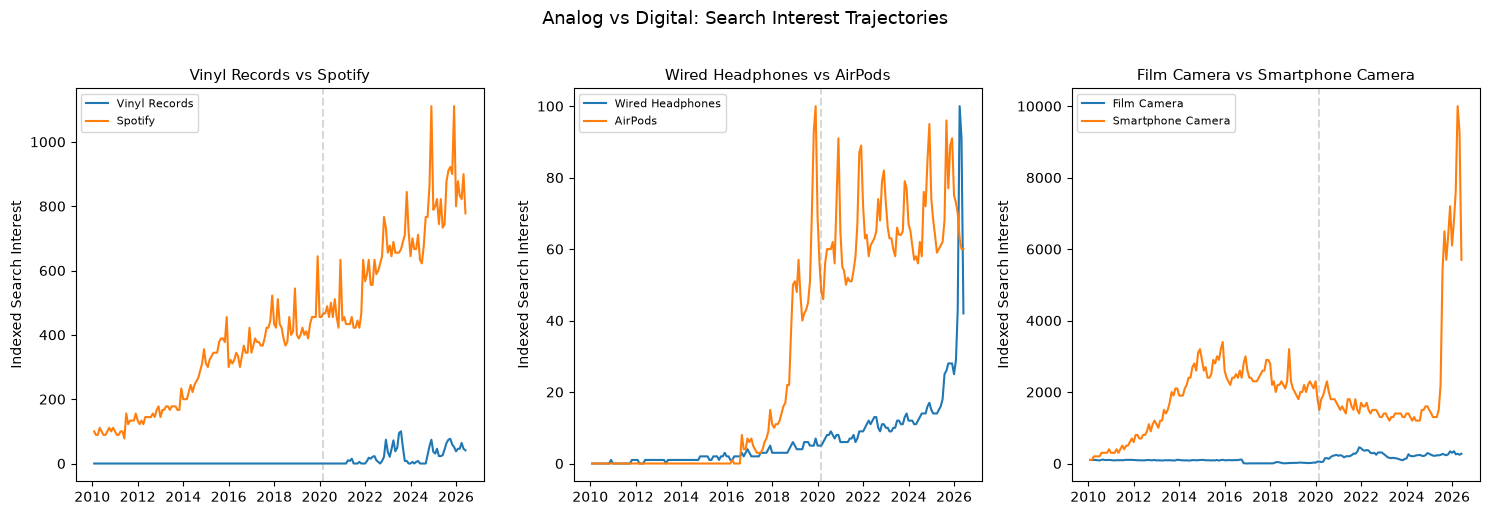

In [47]:
#Chart 3: Key analog vs digital pairs
 
pairs = [
    ('Vinyl Records', 'Spotify'),
    ('Wired Headphones', 'AirPods'),
    ('Film Camera', 'Smartphone Camera'),
]
 
# Only plot pairs where both terms loaded
pairs = [(a, d) for a, d in pairs if a in trends_norm.columns and d in trends_norm.columns]
 
if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 5))
    if len(pairs) == 1:
        axes = [axes]
 
    for ax, (analog, digital) in zip(axes, pairs):
        ax.plot(trends_norm.index, trends_norm[analog], label=analog, linewidth=1.5)
        ax.plot(trends_norm.index, trends_norm[digital], label=digital, linewidth=1.5)
        ax.set_title(f'{analog} vs {digital}', fontsize=11)
        ax.set_ylabel('Indexed Search Interest')
        ax.legend(fontsize=8)
        ax.axvline(pd.Timestamp('2020-03-01'), color='grey', linestyle='--', alpha=0.3)
 
    plt.suptitle('Analog vs Digital: Search Interest Trajectories', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('layer1_analog_vs_digital.png', dpi=150)
    plt.show()

In [52]:
#PART 2: SALES DATA
#Aligning both to 2014-2024 for consistent cross-market comparison
riaa = pd.read_csv('riaa_us_music_revenue_by_format_2013_2024.csv')
riaa = riaa[(riaa['year'] >= 2014) & (riaa['year'] <= 2024)]
 
bpi = pd.read_csv('bpi_uk_music_revenue_by_format_2014_2025.csv')
bpi = bpi[(bpi['year'] >= 2014) & (bpi['year'] <= 2024)]

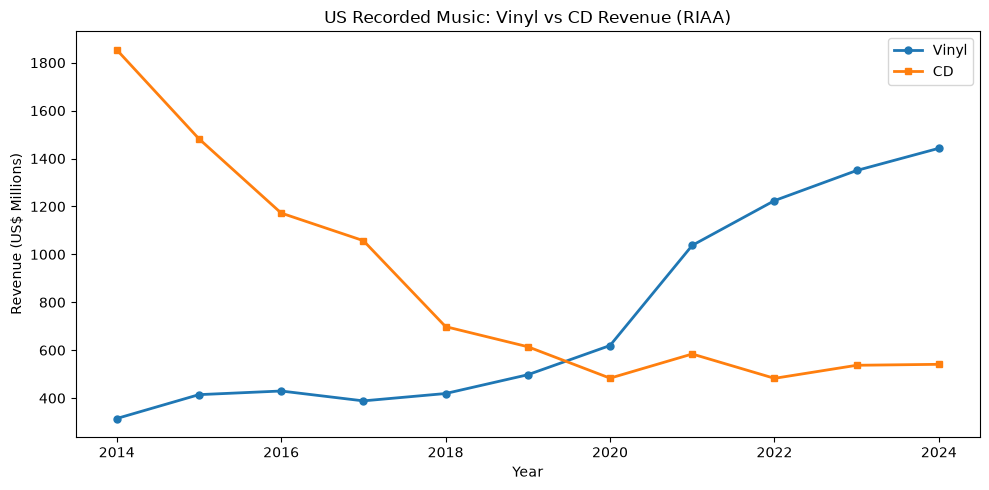

In [53]:
#Chart 4: US Vinyl vs CD revenue
 
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(riaa['year'], riaa['vinyl_revenue_usd_millions'], 'o-',
        label='Vinyl', linewidth=2, markersize=5)
ax.plot(riaa['year'], riaa['cd_revenue_usd_millions'], 's-',
        label='CD', linewidth=2, markersize=5)
 
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (US$ Millions)')
ax.set_title('US Recorded Music: Vinyl vs CD Revenue (RIAA)')
ax.legend()
plt.tight_layout()
plt.savefig('layer2_us_vinyl_vs_cd.png', dpi=150)
plt.show()

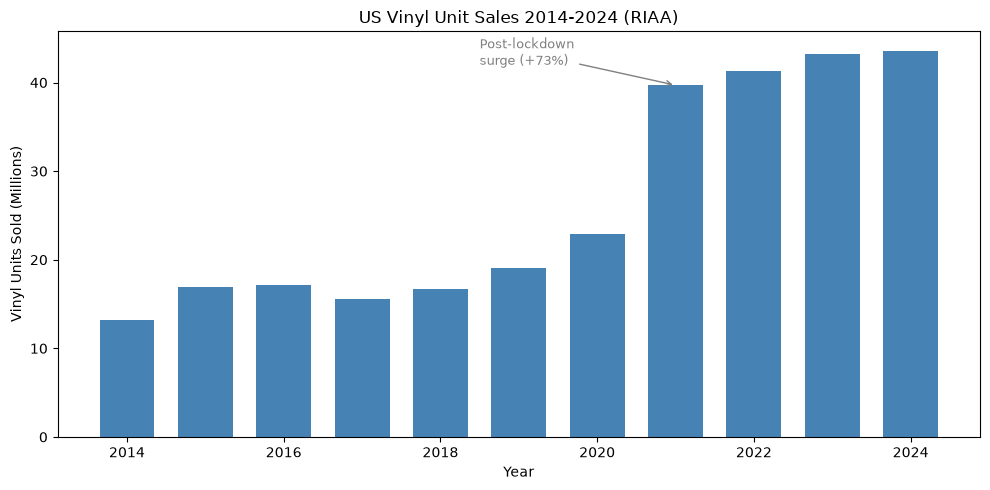

In [54]:
#Chart 5: US Vinyl units over time
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.bar(riaa['year'], riaa['vinyl_units_millions'], color='steelblue', width=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Vinyl Units Sold (Millions)')
ax.set_title('US Vinyl Unit Sales 2014-2024 (RIAA)')
 
# Annotate the 2021 spike
ax.annotate('Post-lockdown\nsurge (+73%)',
            xy=(2021, riaa[riaa['year'] == 2021]['vinyl_units_millions'].values[0]),
            xytext=(2018.5, 42),
            arrowprops=dict(arrowstyle='->', color='grey'),
            fontsize=9, color='grey')
 
plt.tight_layout()
plt.savefig('layer2_us_vinyl_units.png', dpi=150)
plt.show()

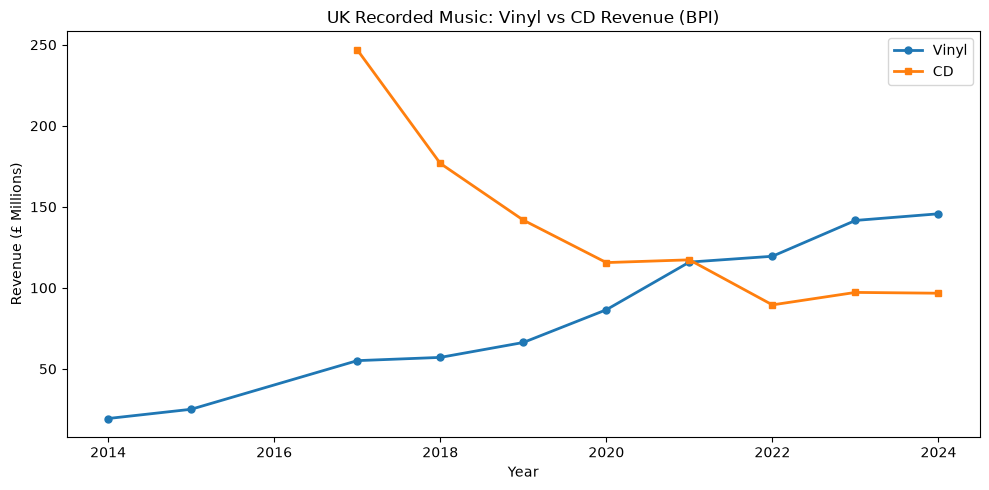

In [55]:
#Chart 6: UK Vinyl vs CD revenue
 
fig, ax = plt.subplots(figsize=(10, 5))
 
bpi_clean = bpi.dropna(subset=['vinyl_revenue_gbp_millions'])
 
ax.plot(bpi_clean['year'], bpi_clean['vinyl_revenue_gbp_millions'], 'o-',
        label='Vinyl', linewidth=2, markersize=5)
ax.plot(bpi_clean['year'], bpi_clean['cd_revenue_gbp_millions'], 's-',
        label='CD', linewidth=2, markersize=5)
 
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (£ Millions)')
ax.set_title('UK Recorded Music: Vinyl vs CD Revenue (BPI)')
ax.legend()
plt.tight_layout()
plt.savefig('layer2_uk_vinyl_vs_cd.png', dpi=150)
plt.show()

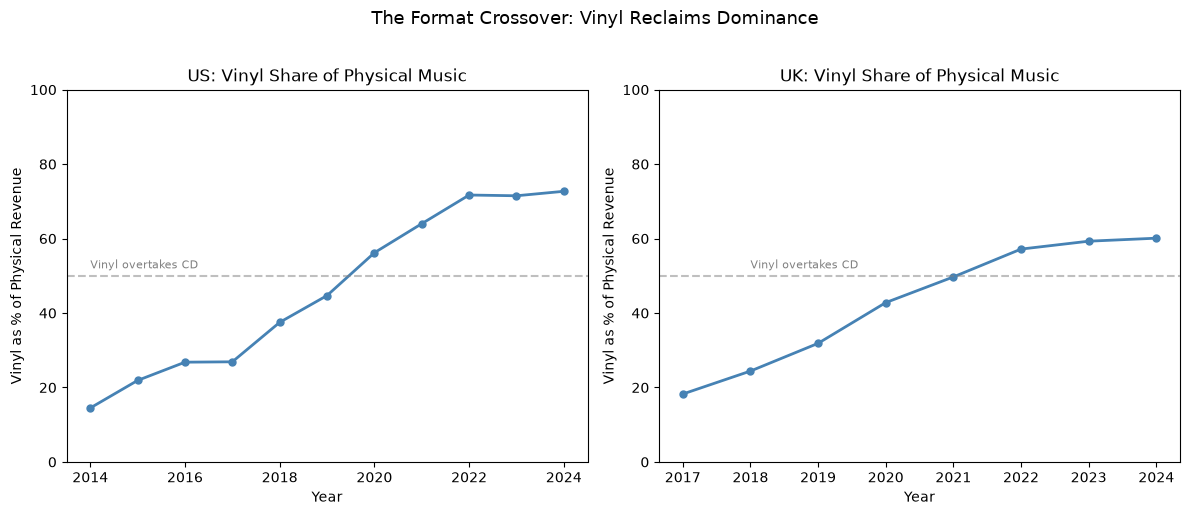

In [56]:
# --- Chart 7: Format crossover summary ---
# Show vinyl's share of physical revenue over time
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
# US
ax1.plot(riaa['year'], riaa['vinyl_share_of_physical_pct'], 'o-',
         color='steelblue', linewidth=2, markersize=5)
ax1.axhline(y=50, color='grey', linestyle='--', alpha=0.5)
ax1.text(2014, 52, 'Vinyl overtakes CD', fontsize=8, color='grey')
ax1.set_xlabel('Year')
ax1.set_ylabel('Vinyl as % of Physical Revenue')
ax1.set_title('US: Vinyl Share of Physical Music')
ax1.set_ylim(0, 100)
 
# UK
bpi_share = bpi_clean.copy()
bpi_share['vinyl_share'] = (
    bpi_share['vinyl_revenue_gbp_millions'] /
    (bpi_share['vinyl_revenue_gbp_millions'] + bpi_share['cd_revenue_gbp_millions']) * 100
)
 
ax2.plot(bpi_share['year'], bpi_share['vinyl_share'], 'o-',
         color='steelblue', linewidth=2, markersize=5)
ax2.axhline(y=50, color='grey', linestyle='--', alpha=0.5)
ax2.text(2018, 52, 'Vinyl overtakes CD', fontsize=8, color='grey')
ax2.set_xlabel('Year')
ax2.set_ylabel('Vinyl as % of Physical Revenue')
ax2.set_title('UK: Vinyl Share of Physical Music')
ax2.set_ylim(0, 100)
 
plt.suptitle('The Format Crossover: Vinyl Reclaims Dominance', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('layer2_format_crossover.png', dpi=150)
plt.show()

In [57]:
print("\nAll Layer 1 & 2 charts saved.")


All Layer 1 & 2 charts saved.
